# BrushCue Example: Zoom Blur

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/zoom_blur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/zoom-blur

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


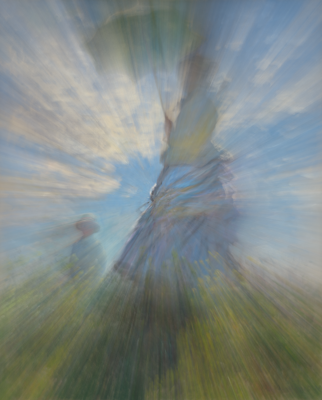

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
graph = input_image.zoom_blur(
    bc.Vector2f.from_components(
        (input_image.bounds().width() / 2.0), (input_image.bounds().height() / 2.0)
    ),
    0.4,
    0.003,
    bc.Point2f.from_components(0.0, 0.0).distance(
        bc.Point2f.from_components(
            input_image.bounds().width(), input_image.bounds().height()
        )
    ),
).crop(input_image.bounds())

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
